In [16]:
%pip install scikit-image
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.util import invert

Note: you may need to restart the kernel to use updated packages.


**GRAYSCALE** => Adaptive threshold => Remove small noise => Binary mask => Skeleton

In [17]:
%pip install torch opencv-python
import torch 

Note: you may need to restart the kernel to use updated packages.


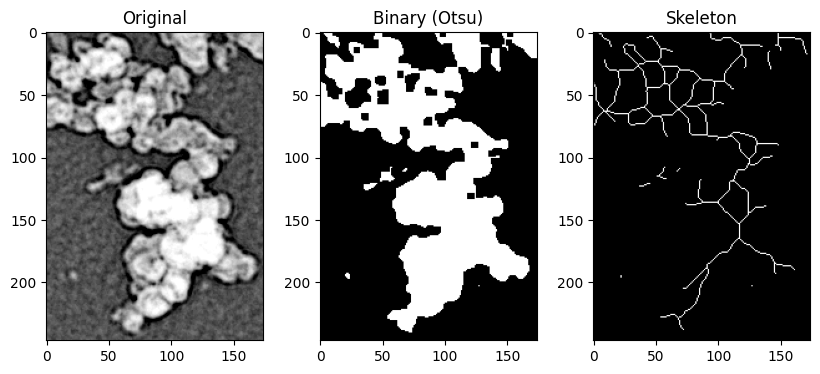

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage import img_as_bool

test_img_path = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\Train-test\Botlek-01-Ori-Ag-3.tif"
test_img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)

# Invert
test_img = cv2.bitwise_not(test_img)

# Gaussian blur để giảm texture nền
blur = cv2.GaussianBlur(test_img, (5,5), 0)

# Otsu threshold
_, binary = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Morph close để nối vùng aggregate
kernel = np.ones((5,5), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# Skeletonize
binary_bool = img_as_bool(binary)
skeleton = skeletonize(binary_bool)

# Show
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(test_img, cmap="gray")
plt.subplot(1,3,2); plt.title("Binary (Otsu)"); plt.imshow(binary, cmap="gray")
plt.subplot(1,3,3); plt.title("Skeleton"); plt.imshow(skeleton, cmap="gray")
plt.show()

In [19]:
import pandas as pd

train_df = pd.read_csv(
    r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\train_data.csv",
    header=None,
    names=["image_path", "label"]
    )
print(train_df.head())

val_df = pd.read_csv(
    r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\val_data.csv",
    header=None,
    names=["image_path", "label"]
)
print(val_df.head())


                                          image_path  label
0                                          file_path  label
1  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
2  C:\Users\Lenovo\OneDrive - Hanoi University of...      3
3  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
4  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
                                          image_path  label
0                                          file_path  label
1  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
2  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
3  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
4  C:\Users\Lenovo\OneDrive - Hanoi University of...      1


In [20]:
#Kiếm tra distribution
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

label
1        3244
3        1268
2         848
0         353
label       1
Name: count, dtype: int64
label
1        1244
3         377
0         264
2         116
label       1
Name: count, dtype: int64


In [21]:
#Data augmentation
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    # normalize theo ImageNet
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    ),
    # regularization mạnh
    transforms.RandomErasing(p=0.2)
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [22]:
from torch.utils.data import Dataset
from PIL import Image
#Xây dataset class bằng cách load ảnh
class CBDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        return img, label

In [23]:
train_df = train_df[train_df["label"] != "label"]
val_df = val_df[val_df["label"] != "label"]

In [24]:
import numpy as np
import torch
from torch.utils.data import WeightedRandomSampler

labels = train_df["label"].astype(int).values

# đếm số sample mỗi class
class_sample_count = np.bincount(labels)

# weight cho mỗi class
class_weights = 1.0 / class_sample_count

# weight cho từng sample
samples_weight = class_weights[labels]

samples_weight = torch.from_numpy(samples_weight).float()

sampler = WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

In [28]:
from torch.utils.data import DataLoader

train_data = CBDataset(train_df, train_tf)
val_data = CBDataset(val_df, val_tf)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    sampler=sampler,
    num_workers=0,
    pin_memory=True,
    transforms=train_tf
)

for img,label in train_loader:
    print("batch loaded")
    break

val_loader = DataLoader(
    val_data, 
    batch_size=32, 
    shuffle=True,
    num_workers=4,
    transforms=val_tf
    )

TypeError: DataLoader.__init__() got an unexpected keyword argument 'transforms'

In [26]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = CBDataset(train_df, transform)

loader = DataLoader(dataset,batch_size=32)

mean = 0
std = 0
n = 0

for images,_ in loader:

    batch_samples = images.size(0)

    images = images.view(batch_samples, images.size(1), -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

    n += batch_samples

mean /= n
std /= n

print(mean,std)

RuntimeError: stack expects each tensor to be equal size, but got [3, 102, 110] at entry 0 and [3, 271, 213] at entry 1

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# load pretrained resnet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# lấy số feature của layer cuối
num_features = model.fc.in_features

# thay fully connected layer cho 4 class
model.fc = nn.Linear(num_features, 4)

In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [ ]:
def mixup_data(x, y, alpha=0.4):

    lam = np.random.beta(alpha, alpha)

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    mixed_x = mixed_x.contiguous()

    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

In [ ]:
%pip install tqdm
from tqdm import tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

def validate():

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

best_acc = 0
patience = 5
counter = 0

num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    print("Start Epoch", epoch+1)

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        images, y_a, y_b, lam = mixup_data(images, labels)

        outputs = model(images)

        loss = lam * criterion(outputs, y_a) + \
               (1-lam) * criterion(outputs, y_b)

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        pbar.set_postfix(loss=loss.item())

    scheduler.step()

    val_acc = validate()
    print(f"Epoch {epoch+1} | Loss {total_loss/len(train_loader):.4f} | Val Acc {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc = val_acc

        counter = 0

        torch.save(model.state_dict(), "best_model.pth")

    else:

        counter += 1

    if counter >= patience:

        print("Early stopping triggered")

        break

Start Epoch 1


  0%|          | 0/179 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

print("Val Accuracy:", correct/total)